## Phase 2✨

 Engineer & Transform Features🔧

📌: In this step
****

i check file path & name

In [71]:
import os
os.listdir()

['.config',
 'cleaning_01.ipynb',
 'clean_ames_data.csv',
 '.ipynb_checkpoints',
 'AmesHousing.csv',
 'Phase_2_features.csv',
 'sample_data']

📌: in this step
****
I executed the phase 1 notebook within phase 2 using %run to reuse the data cleaning steps and continue the project without repeating the code

In [72]:
%run "cleaning_01.ipynb"

1️⃣ Data shape :
 (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null 

# 📍 : Import the all required libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

##Load data 🔃


In [74]:
df=pd.read_csv("clean_ames_data.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Lot Shape,Land Contour,Utilities,Lot Config,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Reg,Lvl,AllPub,Inside,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,IR1,Lvl,AllPub,Corner,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Reg,Lvl,AllPub,Corner,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,3,2010,WD,Normal,189900


### create a copy of the dataset
to work without affecting the original data  ❗

In [75]:
engineer_data=df.copy()

##1️⃣: first step

i displayed all column names in the dataset to understand the available feature before applying feature engineering techniquer .🤔

In [76]:
print(engineer_data.columns.tolist())

['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck SF', 'Open Porch SF

##2️⃣: ONe Hot Encoding

categorical varibles were converted into numerical using pd.get_dummies()

to make them suitable  for analysis.


categorical columns identified to prepare them for encoding

In [77]:
cat_cols=engineer_data.select_dtypes(include="object").columns
print(len(cat_cols))
print(cat_cols)

38
Index(['MS Zoning', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond',
       'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition'],
      dtype='object')


The columns "neighborhood" and "house style" 🚩:


---


were selected for one hot encoding  because they contain important categorical information about the location and structure of the house .

In [78]:
engineer_data=pd.get_dummies(engineer_data,columns=["Neighborhood","House Style"],drop_first=True)

Check if its work ✨

In [79]:
print(engineer_data.shape)

(2930, 109)


##3️⃣Ordinal Encoding.

#check values ✔️
the unique values of 'Kitchen Qual' were displayed to identify the categories

In [80]:
print(engineer_data['Kitchen Qual'].unique())

['TA' 'Gd' 'Ex' 'Fa' 'Po']


the 'Kitchen Qual' column encoded using a predefined mapping

to convert quality levels (Po , Fa,

---

TA,Gd,Ex) into numerical values from 1 to 5 , prederving the natural order.



---

if thair any missing values , map will transforms it into NaN🔎✔️

In [81]:
qual_map={'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5}
engineer_data['Kitchen Qual']=engineer_data['Kitchen Qual'].map(qual_map)

engineer_data['Kitchen Qual'] = engineer_data['Kitchen Qual'].fillna(0)

engineer_data['Kitchen Qual'].head()

,Kitchen Qual
0,3
1,3
2,4
3,5
4,3


 ## 🧮 Feature Engineering

 new feature 'price_per_sqft' were  created to provide more meaningful insights, such as 'price_per_sqft which relates price to size and 'total_bathrooms' which better represents the total bathroom capacity

In [82]:
engineer_data['price_per_sqft']=engineer_data['SalePrice']/engineer_data['Gr Liv Area'].replace(0,1)


A new feature 'total_bathrooms'❗

was created by combining full and half bathrooms to better represent the total bathroom capacity of a house

In [83]:
engineer_data['total_bathrooms']= engineer_data['Full Bath'] +0.5 * engineer_data['Half Bath']

engineer_data['total_bathrooms']=(
  engineer_data['Full Bath']+
  0.5* engineer_data['Half Bath']+
  engineer_data['Bsmt Full Bath']+
  0.5 * engineer_data['Bsmt Half Bath'])

## 🔥 Interaction Feature

An interaction feature 'quality_x_area' was created by multiplying 'Overall Qual' and 'Gr Liv Area' to capture their combined effect.

In [84]:
print('Overall Qual' in engineer_data.columns)

True


In [85]:
engineer_data['quality_x_area']=engineer_data['Overall Qual'] * engineer_data['Gr Liv Area']

## Log Transform 📊

A log transformaiton was applied to the 'saleprice' feature to reduce skewness and make the distribution more normal , which improves analysis and model performance

In [86]:
engineer_data['SalePrice_log']=np.log1p(engineer_data['SalePrice'])

Text(0.5, 1.0, 'Before Log')

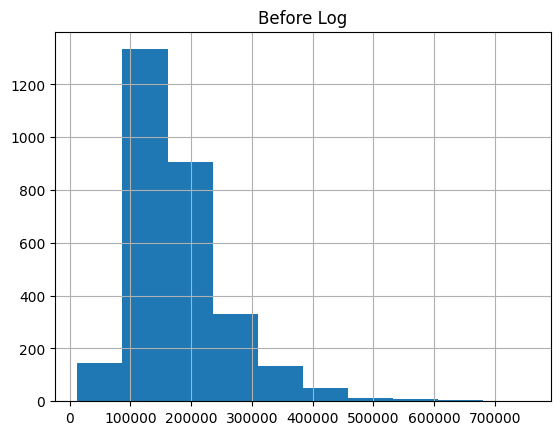

In [87]:
engineer_data['SalePrice'].hist()
plt.title("Before Log")


Text(0.5, 1.0, 'After Log')

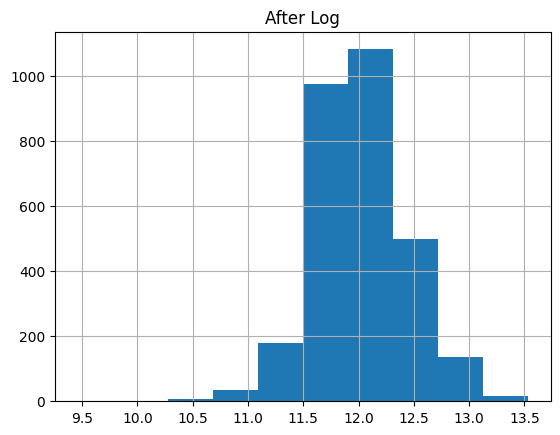

In [88]:
engineer_data['SalePrice_log'].hist()
plt.title("After Log")

## Binning 🚩

The 'house age' feature was grouped into categories to simplify analysis and make patterns easier identify by reducing continuous values into meaningful groups.

In [89]:
engineer_data['House Age'] =2024 - engineer_data['Year Built']

engineer_data['house_age_group']=pd.cut(engineer_data['House Age'],bins=[0,10,30,100],labels=['New','Recent','Old'])

In [90]:
print(engineer_data['house_age_group'].value_counts())

house_age_group
Old       1634
Recent    1019
New          0
Name: count, dtype: int64


## Remove Correlated Features🤔

Highly correlated features were identified and one of each pair was removed to reduce redundancy and prevent multicollinearity, improving model performence

In [91]:
corr=engineer_data.corr(numeric_only=True).abs()

upper=corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool))

to_drop=[col for col in upper.columns if any(upper[col]> 0.95)]

engineer_data.drop(columns=to_drop,inplace=True)

print("Dropped columns:",to_drop)

Dropped columns: ['Yr Sold', 'House Age']


## Feature Scaling 📍

numerical feature were scaled using standardscaler to normalize their values and ensure all features are on similar scale , which helps improve model performance .

In [92]:
print(engineer_data.select_dtypes(include='number').columns)

Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars',
       'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch',
       '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold',
       'SalePrice', 'price_per_sqft', 'total_bathrooms', 'quality_x_area',
       'SalePrice_log'],
      dtype='object')


## Feature Scaling ✨

the columns were scaes using standardscaler to normalize thier values and bring them to a similar scale

In [93]:
x= engineer_data.drop('SalePrice',axis=1)
y=engineer_data['SalePrice']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


scale_cols = ['Gr Liv Area','Lot Area']

scaler = StandardScaler()

x_train[scale_cols]=scaler.fit_transform(x_train[scale_cols])
x_test[scale_cols]=scaler.transform(x_test[scale_cols])
print(x_train[scale_cols].head())
print(x_test[scale_cols].head())

      Gr Liv Area  Lot Area
381     -0.243522  0.033810
834      1.254956  2.307082
1898    -0.532910 -0.035514
678     -0.897619 -0.363746
700      0.412558 -0.310697
      Gr Liv Area  Lot Area
1357     0.343184 -0.624641
2367    -0.917440 -1.023439
2822     0.458146 -0.368467
2126    -0.996725 -0.255660
1544    -1.137455 -0.388593


## Save processed Data🔚

the dataset was saved after completing Phase 2 .✨

In [94]:
engineer_data.to_csv("Phase_2_features.csv")

# The End🔚🌟